In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv("Crop_recommendation.csv")

print("Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded!
Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

=== Missing Values ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== Statistical Summary ===


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
print(f"Total unique crops: {df['label'].nunique()}")
print("Crops:", df['label'].unique())

Total unique crops: 22
Crops: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


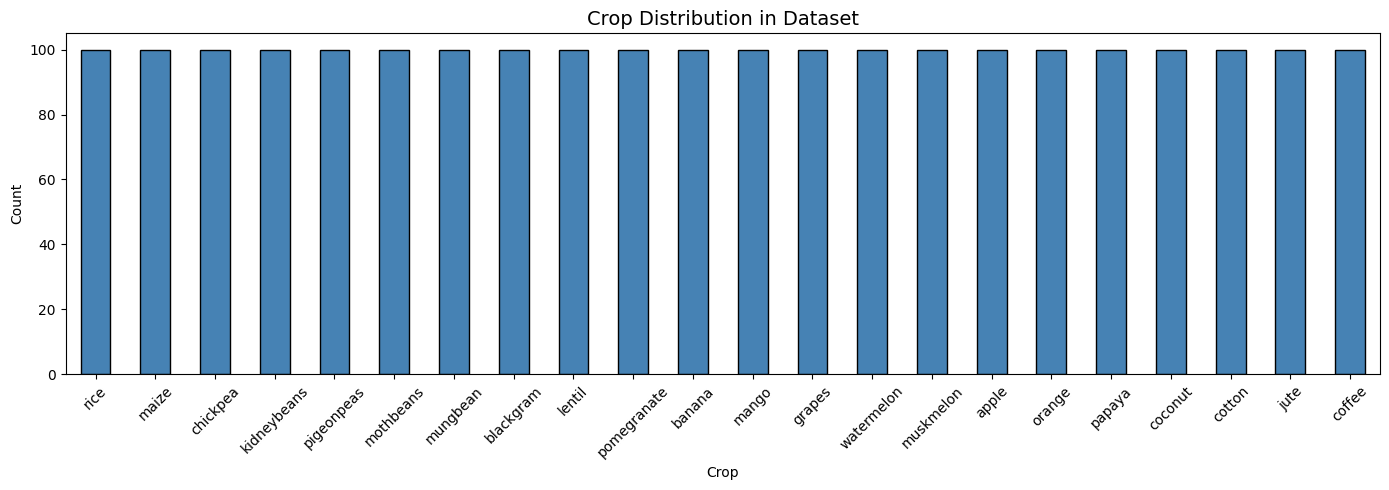

In [ ]:
plt.figure(figsize=(14, 5))
df['label'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Crop Distribution in Dataset', fontsize=14)
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

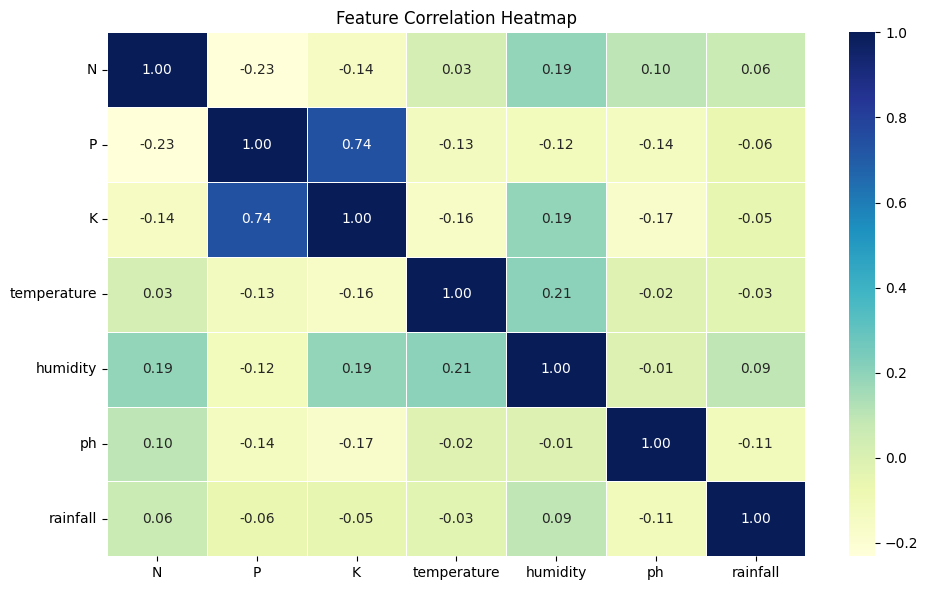

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, fmt='.2f',
            cmap='YlGnBu', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

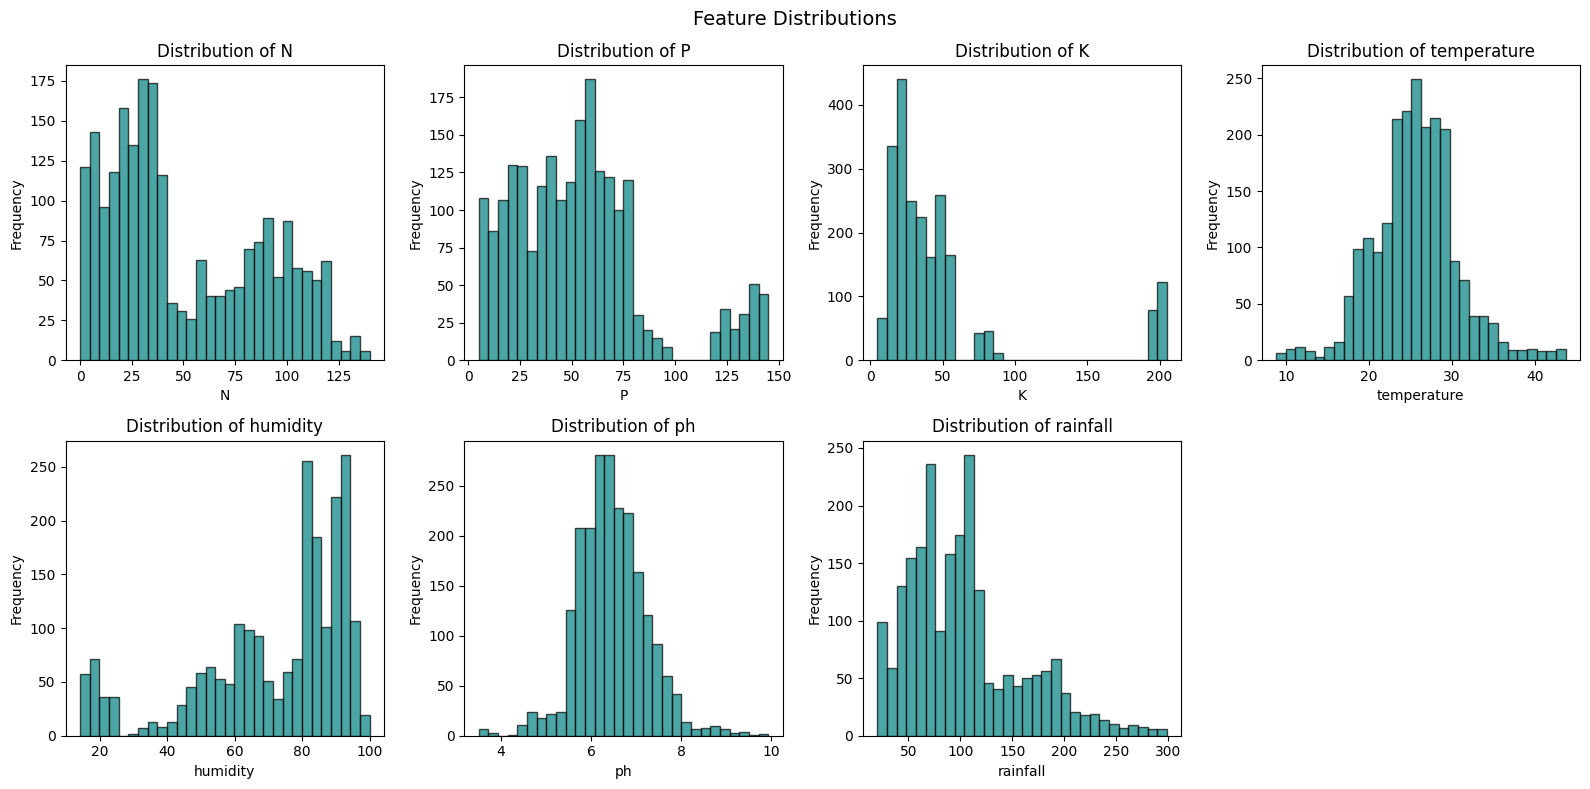

In [ ]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='teal', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

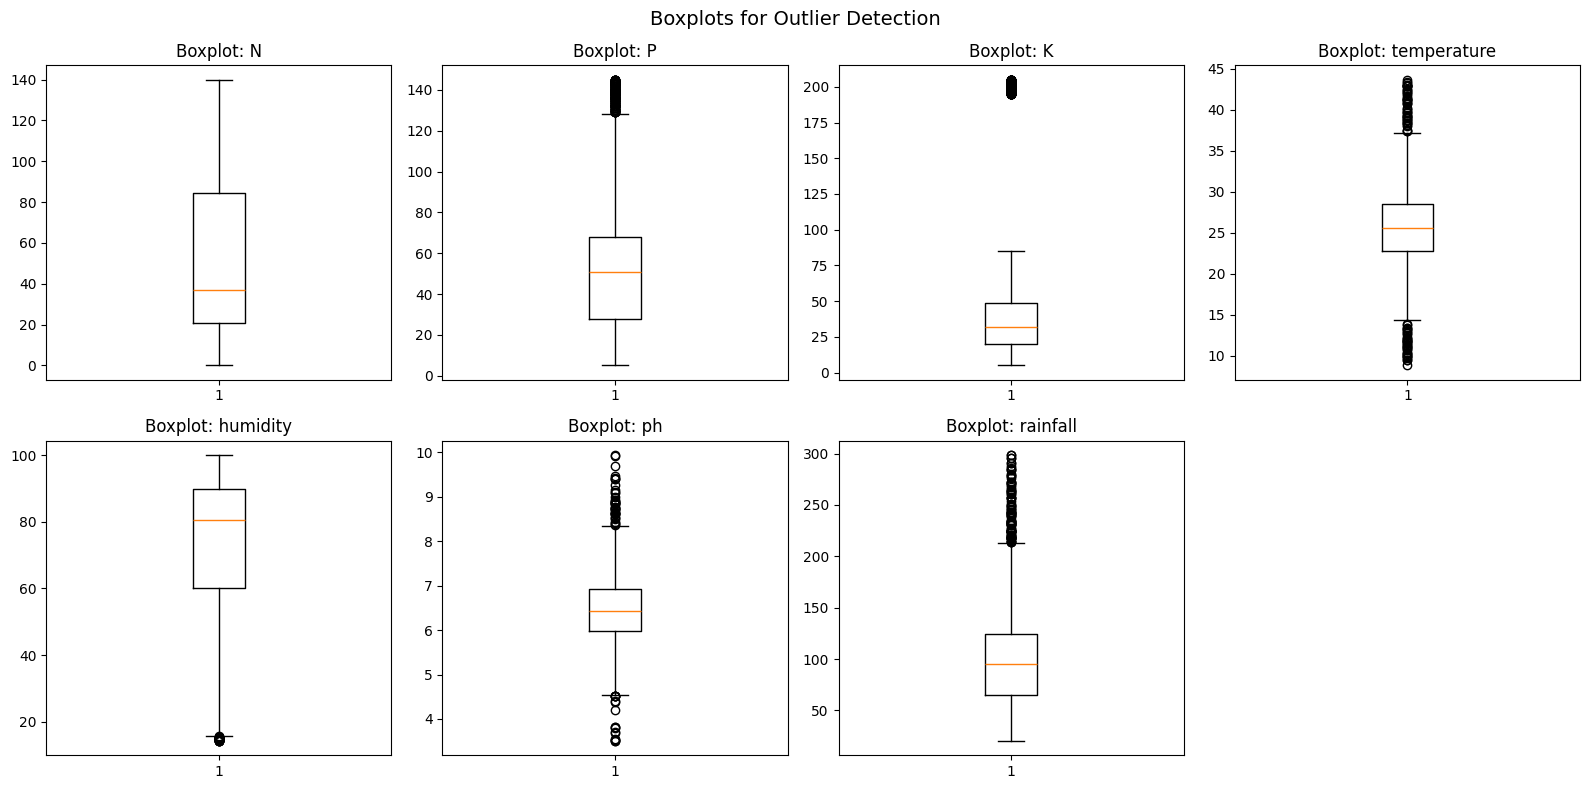

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot: {col}')

axes[-1].axis('off')
plt.suptitle('Boxplots for Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
le = LabelEncoder()
df['crop_encoded'] = le.fit_transform(df['label'])

X = df[features]
y = df['crop_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f" Train size: {X_train.shape}")
print(f" Test  size: {X_test.shape}")

 Train size: (1760, 7)
 Test  size: (440, 7)


In [ ]:
models = {
    "Random Forest"         : RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree"         : DecisionTreeClassifier(random_state=42),
    "Gradient Boosting"     : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes"           : GaussianNB(),
    "SVM"                   : SVC(kernel='rbf', probability=True, random_state=42),
    "KNN"                   : KNeighborsClassifier(n_neighbors=5),
}

results = {}

for name, model in models.items():
    if name in ["SVM", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:<25} → Accuracy: {acc*100:.2f}%")

Random Forest             → Accuracy: 99.55%
Decision Tree             → Accuracy: 97.95%
Gradient Boosting         → Accuracy: 98.86%
Naive Bayes               → Accuracy: 99.55%
SVM                       → Accuracy: 98.41%
KNN                       → Accuracy: 97.95%


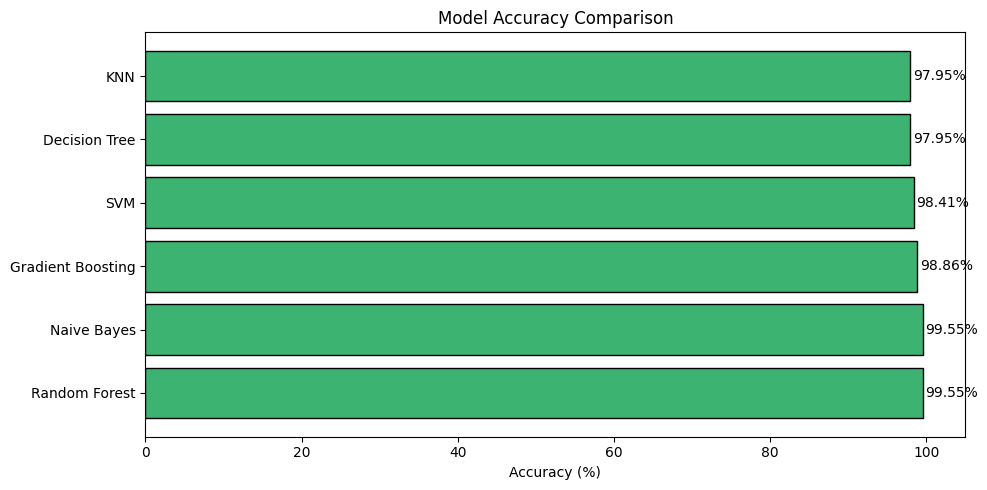


🏆 Best Model: Random Forest with 99.55% accuracy


In [ ]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.barh(results_df['Model'], results_df['Accuracy'] * 100,
                color='mediumseagreen', edgecolor='black')
plt.xlabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 105)

for bar, val in zip(bars, results_df['Accuracy'] * 100):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n🏆 Best Model: {results_df.iloc[0]['Model']} "
      f"with {results_df.iloc[0]['Accuracy']*100:.2f}% accuracy")

In [ ]:
best_model = models["Random Forest"]
y_pred_best = best_model.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred_best,
      target_names=le.classes_))

=== Classification Report ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        

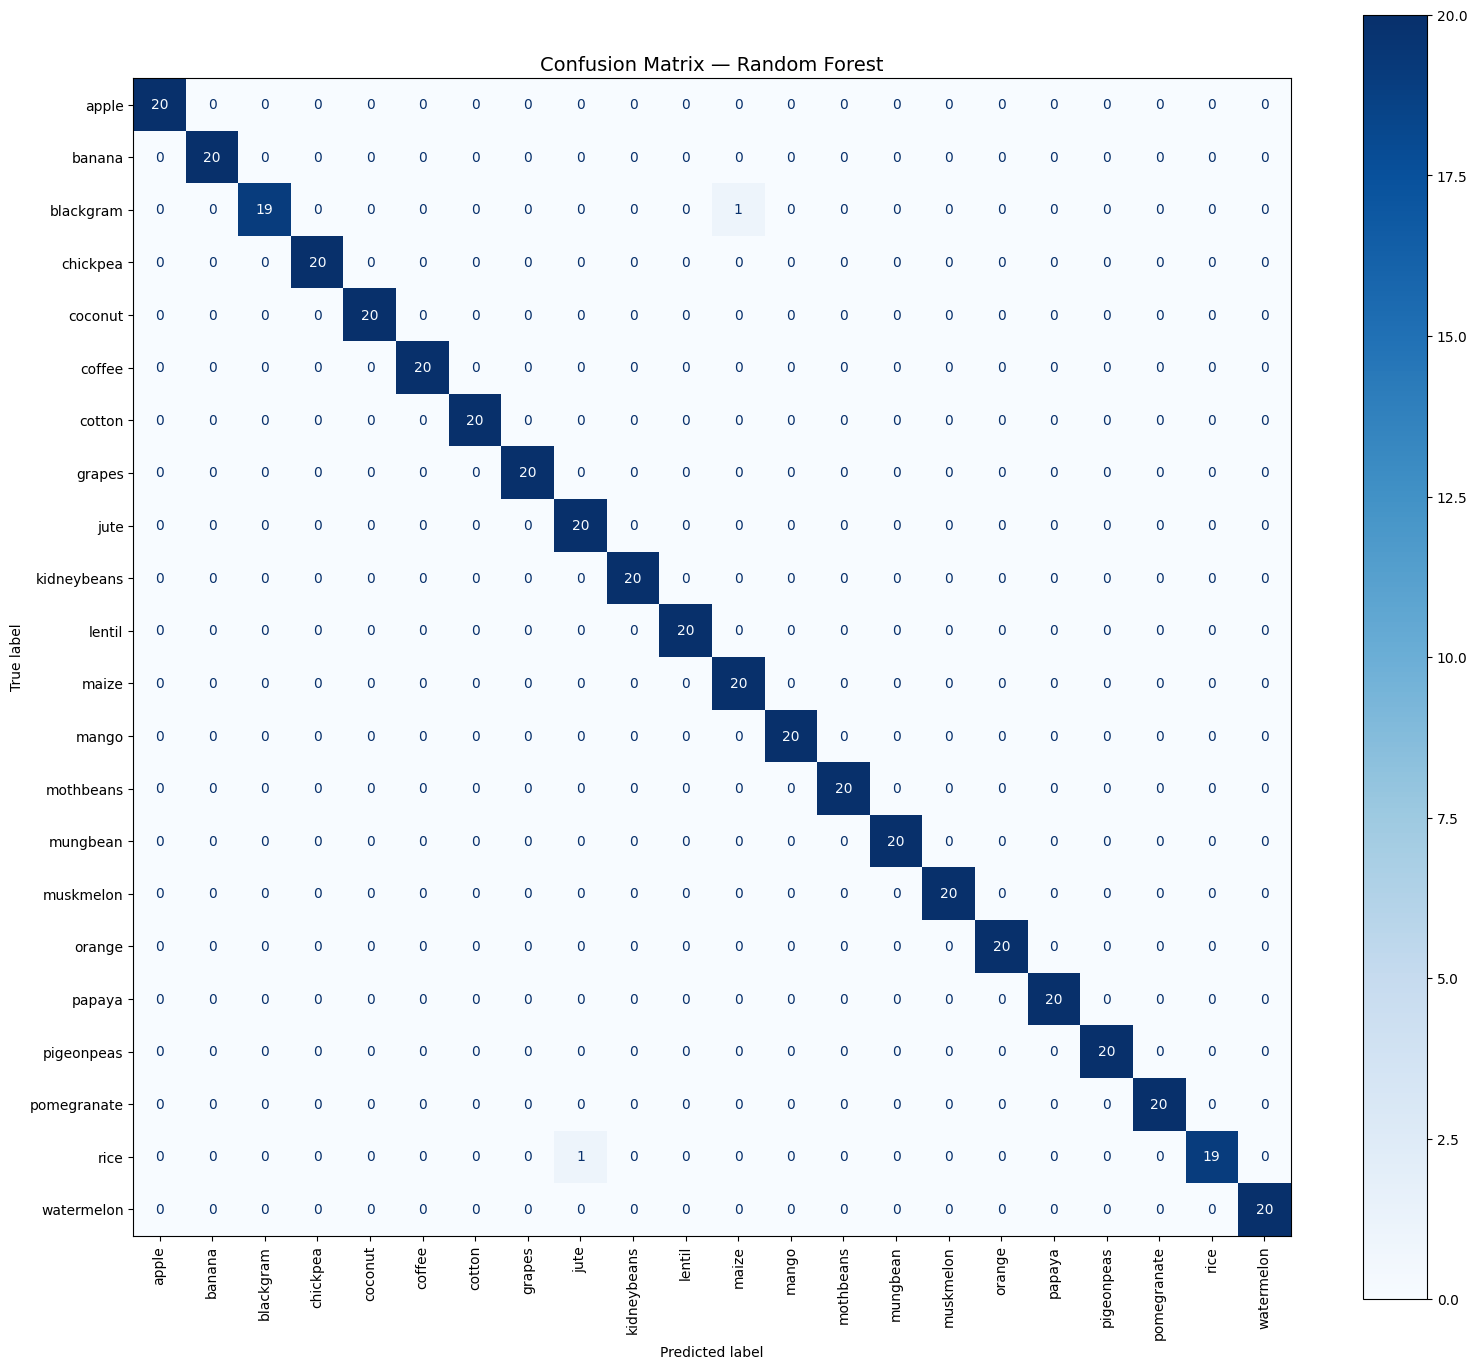

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le.classes_)
disp.plot(cmap='Blues', ax=plt.gca(), xticks_rotation=90)
plt.title('Confusion Matrix — Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

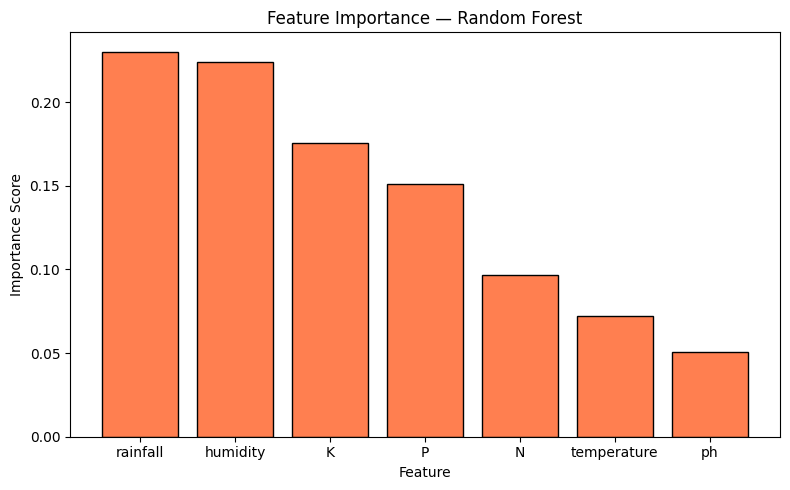

In [ ]:
importances = best_model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(feat_df['Feature'], feat_df['Importance'],
        color='coral', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    """
    Input soil and climate conditions → Returns recommended crop
    """
    input_data = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    prediction = best_model.predict(input_data)
    crop_name  = le.inverse_transform(prediction)[0]
    return crop_name

crop = predict_crop(
    N=90, P=42, K=43,
    temperature=20.5,
    humidity=82.0,
    ph=6.5,
    rainfall=202.0
)
print(f"🌱 Recommended Crop: {crop.upper()}")

🌱 Recommended Crop: RICE


In [ ]:
print("=" * 45)
print("   🌾 CROP RECOMMENDATION SYSTEM")
print("=" * 45)

N           = float(input("Enter Nitrogen (N)       : "))
P           = float(input("Enter Phosphorous (P)    : "))
K           = float(input("Enter Potassium (K)      : "))
temperature = float(input("Enter Temperature (°C)  : "))
humidity    = float(input("Enter Humidity (%)       : "))
ph          = float(input("Enter Soil pH            : "))
rainfall    = float(input("Enter Rainfall (mm)      : "))

result = predict_crop(N, P, K, temperature, humidity, ph, rainfall)

print("\n" + "=" * 45)
print(f"  RECOMMENDED CROP → {result.upper()}")
print("=" * 45)

   🌾 CROP RECOMMENDATION SYSTEM
Enter Nitrogen (N)       : 69
Enter Phosphorous (P)    : 13
Enter Potassium (K)      : 51
Enter Temperature (°C)  : 63
Enter Humidity (%)       : 82
Enter Soil pH            : 3
Enter Rainfall (mm)      : 333

  RECOMMENDED CROP → RICE


In [ ]:
import joblib

joblib.dump(best_model, 'crop_model.pkl')
joblib.dump(scaler,     'crop_scaler.pkl')
joblib.dump(le,         'crop_label_encoder.pkl')

print(" Model saved as crop_model.pkl")
print(" Scaler saved as crop_scaler.pkl")
print(" Label Encoder saved as crop_label_encoder.pkl")